In [ ]:
# ============================
# 1. IMPORTS E CONFIGURAÇÃO
# ============================
import requests
import pandas as pd
import numpy as np
import io
import re
import string
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Se for a primeira execução, descomente estas linhas:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ============================
# 2. PARÂMETROS GERAIS
# ============================

# Quantos dias para trás considerar (fácil de alterar)
DAYS_BACK = 90  # altere para 90, 180, 365, etc., se quiser mais histórico

BASE_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

# Datas (hoje e limite mínimo)
today = datetime.utcnow().date()
date_received_max = today.strftime("%Y-%m-%d")
date_received_min = (today - timedelta(days=DAYS_BACK)).strftime("%Y-%m-%d")

print("Coletando dados de", date_received_min, "até", date_received_max)


Coletando dados de 2025-12-21 até 2026-03-21


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
/tmp/ipykernel_206/4076638015.py:44: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow().date()


In [ ]:
import requests
import pandas as pd
import io

BASE_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

def fetch_complaints(date_min: str, date_max: str, max_size: int = 50000) -> pd.DataFrame:
    """
    Busca reclamações na API pública do CFPB no intervalo [date_min, date_max].
    - date_min, date_max: strings no formato 'YYYY-MM-DD'
    - max_size: número máximo total de registros desejados (vamos paginar em lotes de até 10000)
    Retorna um DataFrame com os dados.
    """

    # A API documenta retorno em json/csv/xls/xlsx e suporta paginação via 'page' e 'size',
    # com limite típico de 10000 por página.[web:57]
    PAGE_SIZE = 10000
    size = min(PAGE_SIZE, max_size)

    headers = {
        # Coloque algo identificável seu aqui (pode incluir email institucional)
        "User-Agent": "POS-TECH-Datathon/1.0 (Google Colab; contato: seu_email@exemplo.com)"
    }

    all_dfs = []
    total_fetched = 0
    page = 1

    while total_fetched < max_size:
        params = {
            "date_received_min": date_min,
            "date_received_max": date_max,
            "has_narrative": "true",
            "no_aggs": "true",
            "field": "all",
            "format": "csv",   # a API suporta csv/json/xls/xlsx[web:57]
            "size": size,
            "page": page
        }

        print(f"Buscando página {page} (size={size})...")
        resp = requests.get(BASE_URL, params=params, headers=headers, timeout=30)

        # Debug rápido se ainda der problema
        print("Status code:", resp.status_code)
        if resp.status_code == 403:
            print("Resposta 403 - Forbidden. Tente rodar de outro ambiente (sem VPN) "
                  "ou reduzir ainda mais o size, por exemplo size=1000.")
            resp.raise_for_status()

        resp.raise_for_status()

        csv_data = io.StringIO(resp.text)
        df_page = pd.read_csv(csv_data)

        if df_page.empty:
            print("Página vazia, encerrando paginação.")
            break

        all_dfs.append(df_page)
        fetched = len(df_page)
        total_fetched += fetched
        print(f"Página {page}: {fetched} registros. Total acumulado: {total_fetched}.")

        if fetched < size:
            # Última página (não há mais dados)
            break

        page += 1

    if not all_dfs:
        return pd.DataFrame()

    df = pd.concat(all_dfs, ignore_index=True)
    return df

# Uso:
df_raw = fetch_complaints(date_received_min, date_received_max, max_size=50000)
print("Registros brutos retornados:", df_raw.shape)
df_raw.head()


Buscando página 1 (size=10000)...
Status code: 200
Página 1: 36096 registros. Total acumulado: 36096.
Buscando página 2 (size=10000)...
Status code: 200
Página 2: 36096 registros. Total acumulado: 72192.
Registros brutos retornados: (72192, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,12/22/25,Student loan,Private student loan,Issue where my lender is my school,Issues with fees connected to the loan,My spouse and I attended XXXX XXXX XXXX from X...,NaN,"Maximus Federal Services, Inc.",TX,75243,NaN,Consent provided,Web,12/22/25,Closed with explanation,Yes,NaN,18232083
1,12/23/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am writing to formal...",Company believes it acted appropriately as aut...,NAVY FEDERAL CREDIT UNION,NC,28311,NaN,Consent provided,Web,12/23/25,Closed with non-monetary relief,Yes,NaN,18239740
2,02/19/26,Credit card,General-purpose credit card or charge card,Fees or interest,Problem with fees,I had a CITI bank Best Buy card account ending...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",FL,32246,NaN,Consent provided,Web,02/19/26,Closed with monetary relief,Yes,NaN,19620152
3,12/22/25,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A Macy 's credit card was opened under my name...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,752XX,NaN,Consent provided,Web,12/22/25,Closed with explanation,Yes,NaN,18219388
4,01/22/26,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,"On XX/XX/year>, I used my Citi bank credit car...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",OH,45215,NaN,Consent provided,Web,01/22/26,Closed with explanation,Yes,NaN,18917331


In [ ]:
# ============================
# 4. CRIAÇÃO DA VARIÁVEL ALVO (SENTIMENTO)
# ============================

# Garantir que as colunas esperadas existam (nominadas conforme o CSV da API)
expected_cols = [
    "Date received",
    "Product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company",
    "State",
    "Company response to consumer",
    "Timely response?",
    "Consumer disputed?",
    "Complaint ID"
]
missing = [c for c in expected_cols if c not in df_raw.columns]
if missing:
    print("ATENÇÃO: Colunas faltantes na resposta da API:", missing)

def rule_based_sentiment(row):
    """
    Define sentimento com base na resposta da empresa e se o consumidor disputou.
    Retorna 'positive', 'negative' ou None (para descartar).
    """
    resp = str(row.get("Company response to consumer", "")).lower()
    disputed = str(row.get("Consumer disputed?", "")).lower()

    # Caso claramente positivo: houve algum tipo de alívio e o consumidor não disputou
    if ("closed with monetary relief" in resp or
        "closed with non-monetary relief" in resp) and "no" in disputed:
        return "positive"

    # Caso padrão: tratamos como negativo (insatisfação, disputa, sem alívio claro, etc.)
    if resp.strip() != "":
        return "negative"

    # Se não temos informação de resposta, podemos descartar
    return None

df = df_raw.copy()
df["sentiment"] = df.apply(rule_based_sentiment, axis=1)

# Remove linhas sem sentimento definido
df = df[df["sentiment"].notna()].reset_index(drop=True)

print("Distribuição de sentimento:")
print(df["sentiment"].value_counts())


Distribuição de sentimento:
sentiment
negative    72192
Name: count, dtype: int64


In [ ]:
# ============================
# 5. PRÉ-PROCESSAMENTO DO TEXTO
# ============================

TEXT_COL = "Consumer complaint narrative"

# Remove linhas sem texto
df = df[df[TEXT_COL].notna()].reset_index(drop=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Limpa e normaliza o texto:
    - lowercase
    - remove URLs, números, pontuação
    - remove stopwords
    - aplica lematização
    """
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)

    # Mantém apenas letras e espaço
    text = re.sub(r"[^a-z\\s]", " ", text)

    # Tokenização simples por espaço
    tokens = text.split()

    # Remove stopwords e lematiza
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 2
    ]

    return " ".join(tokens)

# Cria coluna com texto limpo
df["clean_text"] = df[TEXT_COL].astype(str).apply(clean_text)

# Remove entradas com texto limpo vazio (se houver)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print("Exemplo de texto original vs limpo:")
for i in range(3):
    print("Original:", df.loc[i, TEXT_COL][:200])
    print("Limpo  :", df.loc[i, "clean_text"][:200])
    print("-" * 80)


Exemplo de texto original vs limpo:
Original: My spouse and I attended XXXX XXXX XXXX from XXXX. The school closed due in XXXX to fraudulent situations involving theft by the XXXX in which had nothing to do with our education still but it is affe
Limpo  : spouse attended xxxx xxxx xxxx xxxx school closed due xxxx fraudulent situation involving theft xxxx nothing education still affecting ive learned school accredited institution enrollment told could u
--------------------------------------------------------------------------------
Original: To Whom It May Concern, I am writing to formally dispute the accuracy and continued reporting of hard inquiries, closed accounts, and a charged-off account appearing on my credit report.

Under the Fa
Limpo  : may concern writing formally dispute accuracy continued reporting hard inquiry closed account charged account appearing credit report fair credit reporting act credit reporting agency required report 
-----------------------------------------

In [ ]:
# ============================
# 6. SPLIT TREINO/TESTE E TOKENIZAÇÃO
# ============================

X = df["clean_text"].values
y = df["sentiment"].map({"negative": 0, "positive": 1}).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

MAX_WORDS = 20000   # vocabulário (pode ajustar)
MAX_LEN = 200       # tamanho máximo da sequência (pode ajustar)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Converte textos em sequências de índices
seq_train = tokenizer.texts_to_sequences(X_train)
seq_test = tokenizer.texts_to_sequences(X_test)

# Pad/truncate para comprimento fixo
X_train_pad = pad_sequences(seq_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(seq_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("Shape X_train_pad:", X_train_pad.shape)
print("Shape X_test_pad :", X_test_pad.shape)


Shape X_train_pad: (57753, 200)
Shape X_test_pad : (14439, 200)


In [ ]:
# ============================
# 7. MODELO DE DEEP LEARNING
# ============================

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBED_DIM = 100      # dimensão do embedding
LSTM_UNITS = 64

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    tf.keras.layers.GlobalMaxPool1D(),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

EPOCHS = 5       # ajuste conforme sua infra
BATCH_SIZE = 128

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Avaliação no conjunto de teste
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Acurácia em teste: {test_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 302s 727ms/step - accuracy: 0.9983 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 6.2634e-08
Epoch 2/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 305s 749ms/step - accuracy: 1.0000 - loss: 1.2747e-05 - val_accuracy: 1.0000 - val_loss: 1.1360e-08
Epoch 3/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 292s 719ms/step - accuracy: 1.0000 - loss: 7.2702e-06 - val_accuracy: 1.0000 - val_loss: 2.8291e-09
Epoch 4/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 291s 714ms/step - accuracy: 1.0000 - loss: 2.5723e-06 - val_accuracy: 1.0000 - val_loss: 8.1816e-10
Epoch 5/5
407/407 ━━━━━━━━━━━━━━━━━━━━ 294s 722ms/step - accuracy: 1.0000 - loss: 1.9636e-06 - val_accuracy: 1.0000 - val_loss: 2.6122e-10
Acurácia em teste: 1.0000


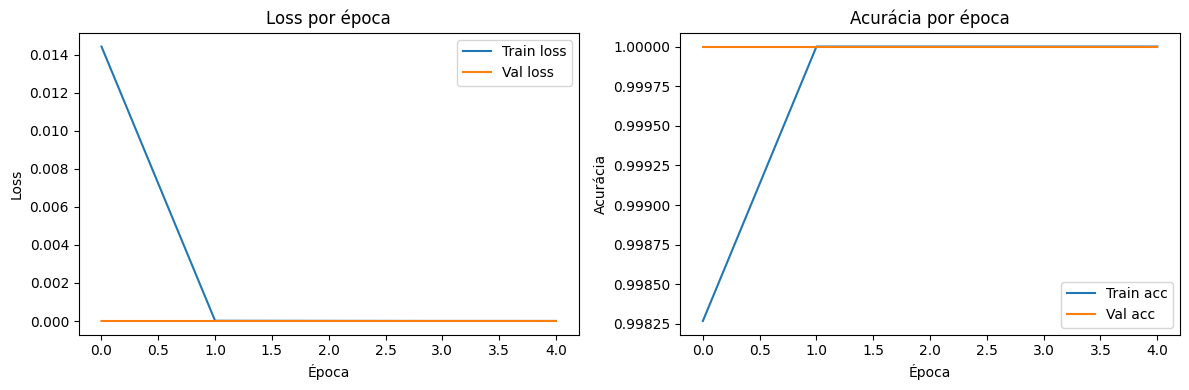

452/452 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


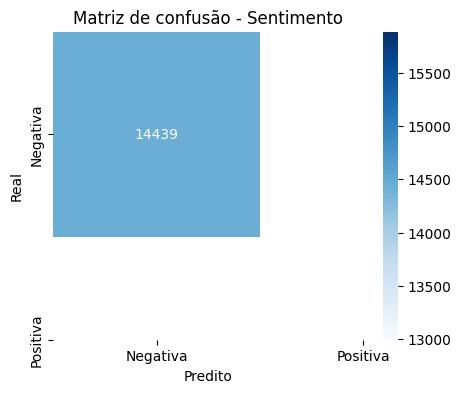

ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

In [ ]:
# ============================
# 8. GRÁFICOS DE PERFORMANCE DO MODELO
# ============================

# Curvas de loss e accuracy
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["val_accuracy"], label="Val acc")
plt.title("Acurácia por época")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()

plt.tight_layout()
plt.show()

# Matriz de confusão
y_pred_prob = model.predict(X_test_pad).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativa", "Positiva"],
            yticklabels=["Negativa", "Positiva"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão - Sentimento")
plt.show()

print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))
